# EDA - NYC Taxi Trip Duration

## 1. Setup & Imports
This section imports libraries and declares constants used for quality checks and feature engineering.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = (
    Path.cwd().resolve().parents[0]
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
DATA_PATH = ROOT / "data" / "train.csv"
FIG_DIR = ROOT / "figures"
REPORTS_DIR = ROOT / "reports"

NYC_LAT_MIN, NYC_LAT_MAX = 40.4, 41.0
NYC_LON_MIN, NYC_LON_MAX = -74.3, -73.7

FIG_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

## 2. Data Loading
Load train.csv and parse datetime fields.

In [2]:
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["pickup_datetime", "dropoff_datetime"],
)

df.shape

(1458644, 11)

In [3]:
df.dtypes

id                               str
vendor_id                      int64
pickup_datetime       datetime64[us]
dropoff_datetime      datetime64[us]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag               str
trip_duration                  int64
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[us](2), float64(4), int64(3), str(2)
memory usage: 122.4 MB


In [5]:
df.describe(include="all")

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
count,1458644,1.458644e+06,1458644,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1458644,1.458644e+06
unique,1458644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,id2875421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1450599,NaN
mean,NaN,1.534950e+00,2016-04-01 10:10:24.940038,2016-04-01 10:26:24.432309,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,NaN,9.594923e+02
min,NaN,1.000000e+00,2016-01-01 00:00:17,2016-01-01 00:03:31,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,NaN,1.000000e+00
25%,NaN,1.000000e+00,2016-02-17 16:46:04.250000,2016-02-17 17:05:32.500000,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,NaN,3.970000e+02
50%,NaN,2.000000e+00,2016-04-01 17:19:40,2016-04-01 17:35:12,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,NaN,6.620000e+02
75%,NaN,2.000000e+00,2016-05-15 03:56:08.750000,2016-05-15 04:10:51.750000,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,NaN,1.075000e+03
max,NaN,2.000000e+00,2016-06-30 23:59:39,2016-07-01 23:02:03,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,NaN,3.526282e+06


In [6]:
print("Date range:", df["pickup_datetime"].min(), "to", df["pickup_datetime"].max())
print("Memory (MB):", round(df.memory_usage(deep=True).sum() / (1024**2), 2))

Date range: 2016-01-01 00:00:17 to 2016-06-30 23:59:39
Memory (MB): 250.39


## 3. Data Quality Assessment
Compute missing values, coordinate bounds, duration anomalies, temporal consistency, and passenger anomalies.

In [7]:
missing_counts = df.isnull().sum()
missing_counts

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [8]:
pickup_valid = df["pickup_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX) & df[
    "pickup_longitude"
].between(NYC_LON_MIN, NYC_LON_MAX)
dropoff_valid = df["dropoff_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX) & df[
    "dropoff_longitude"
].between(NYC_LON_MIN, NYC_LON_MAX)

invalid_pickup = (~pickup_valid).sum()
invalid_dropoff = (~dropoff_valid).sum()
invalid_either = (~pickup_valid | ~dropoff_valid).sum()

invalid_pickup, invalid_dropoff, invalid_either

(np.int64(247), np.int64(971), np.int64(985))

In [9]:
duration = df["trip_duration"]
duration_percentiles = duration.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
duration_lt_60 = (duration < 60).sum()
duration_gt_24h = (duration > 86400).sum()

duration_percentiles, duration_lt_60, duration_gt_24h

(0.01      87.0
 0.05     180.0
 0.25     397.0
 0.50     662.0
 0.75    1075.0
 0.95    2104.0
 0.99    3440.0
 Name: trip_duration, dtype: float64,
 np.int64(8595),
 np.int64(4))

In [10]:
temporal_inconsistent = (df["pickup_datetime"] >= df["dropoff_datetime"]).sum()
delta_seconds = (df["dropoff_datetime"] - df["pickup_datetime"]).dt.total_seconds()
duration_mismatch = (delta_seconds != df["trip_duration"]).sum()

temporal_inconsistent, duration_mismatch

(np.int64(0), np.int64(0))

In [11]:
passenger_counts = df["passenger_count"].value_counts().sort_index()
zero_passengers = (df["passenger_count"] == 0).sum()
passengers_gt_6 = (df["passenger_count"] > 6).sum()

passenger_counts, zero_passengers, passengers_gt_6

(passenger_count
 0         60
 1    1033540
 2     210318
 3      59896
 4      28404
 5      78088
 6      48333
 7          3
 8          1
 9          1
 Name: count, dtype: int64,
 np.int64(60),
 np.int64(5))

In [12]:
vendor_counts = df["vendor_id"].value_counts().sort_index()
store_flag_counts = df["store_and_fwd_flag"].value_counts().sort_index()

vendor_counts, store_flag_counts

(vendor_id
 1    678342
 2    780302
 Name: count, dtype: int64,
 store_and_fwd_flag
 N    1450599
 Y       8045
 Name: count, dtype: int64)

## 4. Feature Engineering
Create temporal features, Haversine distance, and estimated speed.

In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return r * c


df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["day_of_month"] = df["pickup_datetime"].dt.day
df["month"] = df["pickup_datetime"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6])
df["haversine_km"] = haversine_km(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"],
)
df["speed_kmh"] = df["haversine_km"] / (df["trip_duration"].replace(0, np.nan) / 3600)

df[["hour", "day_of_week", "haversine_km", "speed_kmh"]].head()

,hour,day_of_week,haversine_km,speed_kmh
0,17,0,1.498521,11.856428
1,0,6,1.805507,9.803659
2,11,1,6.385098,10.822201
3,19,2,1.485498,12.465721
4,13,5,1.188588,9.836594


## 5. Temporal Analysis
Create trip volume and speed trend charts by hour.

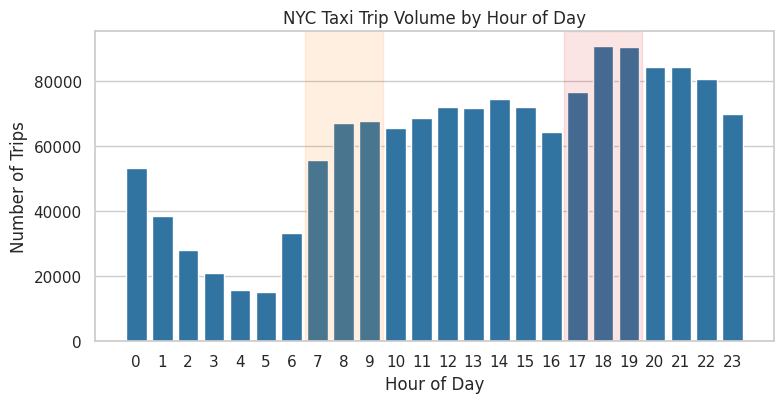

In [14]:
trip_volume_by_hour = df.groupby("hour").size().reindex(range(24), fill_value=0)
speed_by_hour = df.groupby("hour")["speed_kmh"].median().reindex(range(24))

plt.figure(figsize=(8, 4.2))
ax = sns.barplot(
    x=trip_volume_by_hour.index, y=trip_volume_by_hour.values, color="#1f77b4"
)
ax.set_title("NYC Taxi Trip Volume by Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
ax.axvspan(6.5, 9.5, color="#ff7f0e", alpha=0.12)
ax.axvspan(16.5, 19.5, color="#d62728", alpha=0.12)
plt.tight_layout()
plt.savefig(FIG_DIR / "trip_volume_by_hour.png", dpi=300)
plt.show()

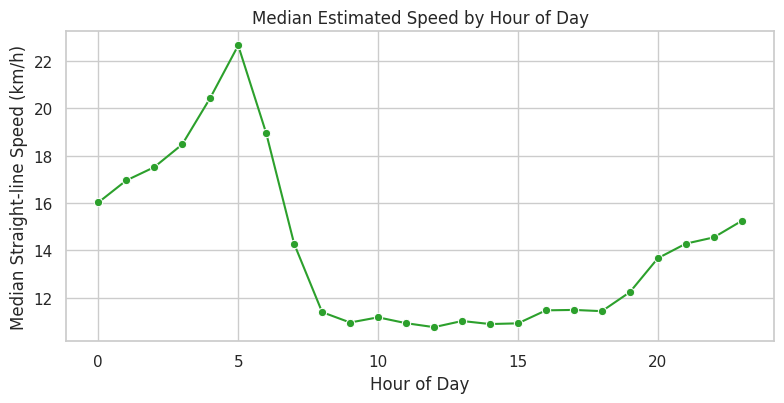

In [15]:
plt.figure(figsize=(8, 4.2))
ax = sns.lineplot(
    x=speed_by_hour.index, y=speed_by_hour.values, marker="o", color="#2ca02c"
)
ax.set_title("Median Estimated Speed by Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Median Straight-line Speed (km/h)")
plt.tight_layout()
plt.savefig(FIG_DIR / "speed_by_hour.png", dpi=300)
plt.show()

## 6. Duration & Distance Analysis
Visualize log-duration distribution.

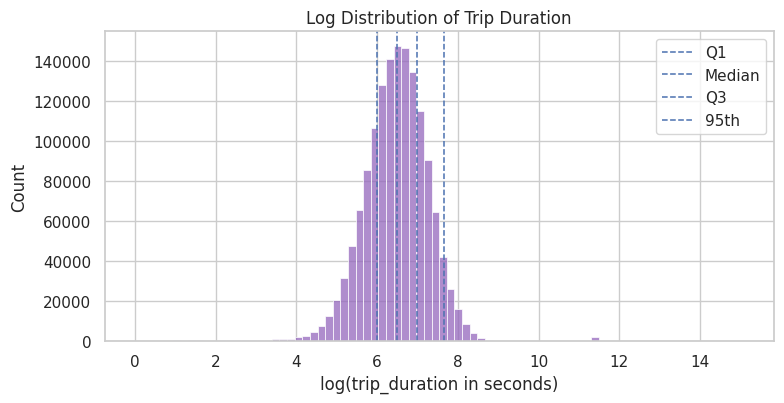

In [16]:
plt.figure(figsize=(8, 4.2))
log_duration = np.log(df["trip_duration"].clip(lower=1))
ax = sns.histplot(log_duration, bins=80, color="#9467bd")
for q, label in zip([0.25, 0.5, 0.75, 0.95], ["Q1", "Median", "Q3", "95th"]):
    ax.axvline(
        np.log(df["trip_duration"].quantile(q)),
        linestyle="--",
        linewidth=1.1,
        label=label,
    )
ax.set_title("Log Distribution of Trip Duration")
ax.set_xlabel("log(trip_duration in seconds)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "duration_distribution.png", dpi=300)
plt.show()

## 7. Spatial Analysis
Sample pickup points to visualize spatial density.

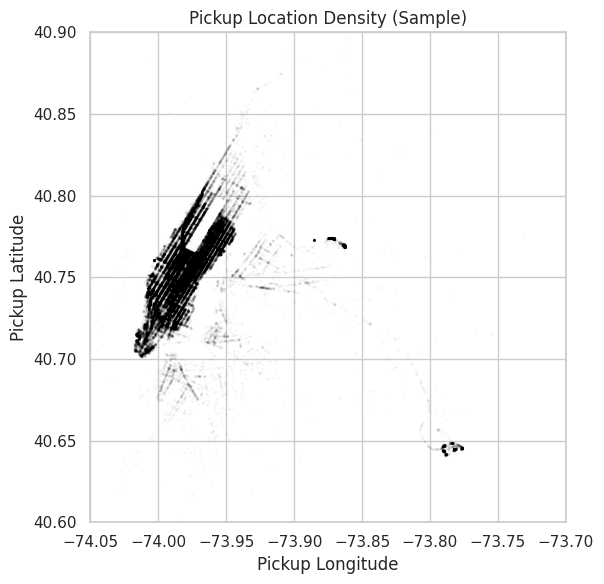

In [17]:
sample = df.sample(n=min(100000, len(df)), random_state=42)
plt.figure(figsize=(6.2, 6))
plt.scatter(
    sample["pickup_longitude"], sample["pickup_latitude"], s=1, alpha=0.02, c="black"
)
plt.xlim(-74.05, -73.70)
plt.ylim(40.60, 40.90)
plt.title("Pickup Location Density (Sample)")
plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")
plt.tight_layout()
plt.savefig(FIG_DIR / "pickup_scatter.png", dpi=300)
plt.show()

## 8. Correlation & Multivariate Analysis
Create a correlation heatmap across key engineered and raw features.

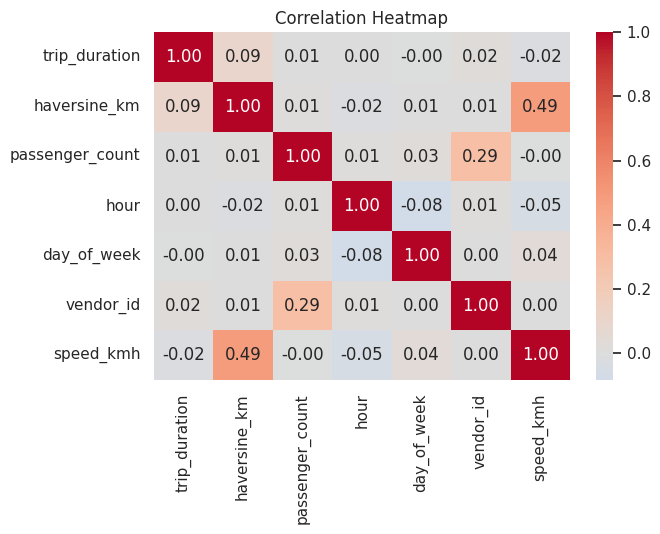

In [18]:
corr_cols = [
    "trip_duration",
    "haversine_km",
    "passenger_count",
    "hour",
    "day_of_week",
    "vendor_id",
    "speed_kmh",
]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

## 9. Key Statistics Summary
Build compact tables for the proposal.

In [19]:
def pct(c, t):
    return (c / t) * 100


total = len(df)
quality_summary = pd.DataFrame(
    [
        {
            "Issue": "Missing values",
            "Count": int(missing_counts.sum()),
            "% of Total": round(pct(int(missing_counts.sum()), total), 4),
        },
        {
            "Issue": "Coords outside NYC bounds",
            "Count": int((~pickup_valid | ~dropoff_valid).sum()),
            "% of Total": round(
                pct(int((~pickup_valid | ~dropoff_valid).sum()), total), 4
            ),
        },
        {
            "Issue": "Duration < 60 seconds",
            "Count": int((df["trip_duration"] < 60).sum()),
            "% of Total": round(pct(int((df["trip_duration"] < 60).sum()), total), 4),
        },
        {
            "Issue": "Duration > 24 hours",
            "Count": int((df["trip_duration"] > 86400).sum()),
            "% of Total": round(
                pct(int((df["trip_duration"] > 86400).sum()), total), 4
            ),
        },
        {
            "Issue": "Zero passengers",
            "Count": int((df["passenger_count"] == 0).sum()),
            "% of Total": round(pct(int((df["passenger_count"] == 0).sum()), total), 4),
        },
        {
            "Issue": "Passengers > 6",
            "Count": int((df["passenger_count"] > 6).sum()),
            "% of Total": round(pct(int((df["passenger_count"] > 6).sum()), total), 4),
        },
        {
            "Issue": "Temporal inconsistencies",
            "Count": int((df["pickup_datetime"] >= df["dropoff_datetime"]).sum()),
            "% of Total": round(
                pct(
                    int((df["pickup_datetime"] >= df["dropoff_datetime"]).sum()), total
                ),
                4,
            ),
        },
    ]
)

quality_summary

,Issue,Count,% of Total
0,Missing values,0,0.0000
1,Coords outside NYC bounds,985,0.0675
2,Duration < 60 seconds,8595,0.5892
3,Duration > 24 hours,4,0.0003
4,Zero passengers,60,0.0041
5,Passengers > 6,5,0.0003
6,Temporal inconsistencies,0,0.0000


In [20]:
key_stats = {
    "Total records": int(total),
    "Features": int(df.shape[1]),
    "Date range": f"{df['pickup_datetime'].min().date()} to {df['pickup_datetime'].max().date()}",
    "Mean trip duration (s)": round(df["trip_duration"].mean(), 2),
    "Median trip duration (s)": round(df["trip_duration"].median(), 2),
    "Std trip duration (s)": round(df["trip_duration"].std(), 2),
    "Mean haversine distance (km)": round(df["haversine_km"].mean(), 3),
    "Median haversine distance (km)": round(df["haversine_km"].median(), 3),
    "Median speed (km/h)": round(df["speed_kmh"].median(), 3),
}

pd.Series(key_stats)

Total records                                      1458644
Features                                                18
Date range                        2016-01-01 to 2016-06-30
Mean trip duration (s)                              959.49
Median trip duration (s)                             662.0
Std trip duration (s)                              5237.43
Mean haversine distance (km)                         3.441
Median haversine distance (km)                       2.094
Median speed (km/h)                                 12.792
dtype: object

## 10. Problem Formulation Notes
Regression, clustering, and classification tasks are documented for Phase 2 implementation.

1. **Task 1 - Trip Duration Prediction (Regression)**: Input temporal/spatial features and predict `trip_duration`.
2. **Task 2 - High-Demand Zone Identification (Clustering)**: Cluster pickup coordinates to derive high-demand zones.
3. **Task 3 - Congestion Level Classification (Classification)**: Classify `(zone, hour, day)` into High/Medium/Low congestion from speed or trip-count labels.